In [1]:
import pickle
import numpy as np
import pandas as pd
import cmcrameri.cm as cm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
with open('../data/results/2026-09-07_19-50_sweep/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

with open('../data/results/2026-09-04_23-30_naive/metadata.pkl', 'rb') as f:
    metadata_naive = pickle.load(f)

# make a dataframe from the metadata
metadata_df = pd.DataFrame(metadata)
metadata_naive_df = pd.DataFrame(metadata_naive)

In [2]:
for bush in metadata_df['bush'].unique():
    for branch in metadata_df[metadata_df['bush'] == bush]['branch'].unique():
        for trial in metadata_df[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch)]['trial'].unique():
            subset = metadata_df[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch) & (metadata_df['trial'] == trial)]
            naive = metadata_naive_df[(metadata_naive_df['bush'] == bush) & (metadata_naive_df['branch'] == branch) & (metadata_naive_df['trial'] == trial)]
            # print(f"Bush: {bush}, Branch: {branch}, Trial: {trial}")
            # print(subset['error'])
            log_err_naive = np.log(naive['sim_stiffness']/naive['field_stiffness'])
            log_err = np.log(subset['sim_stiffness']/subset['field_stiffness'])
            metadata_df.loc[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch) & (metadata_df['trial'] == trial), 'log_err'] = log_err
            metadata_naive_df.loc[(metadata_naive_df['bush'] == bush) & (metadata_naive_df['branch'] == branch) & (metadata_naive_df['trial'] == trial), 'log_err'] = log_err_naive
            # print(log_err)


/tmp/ipykernel_7589/2305541109.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot([min_errors_all, metadata_naive_df['log_err']], vert=False,
/tmp/ipykernel_7589/2305541109.py:40: RuntimeWarning: divide by zero encountered in log
  secax = ax.secondary_xaxis('top', functions=(lambda x: np.exp(x), lambda x: np.log(x)))


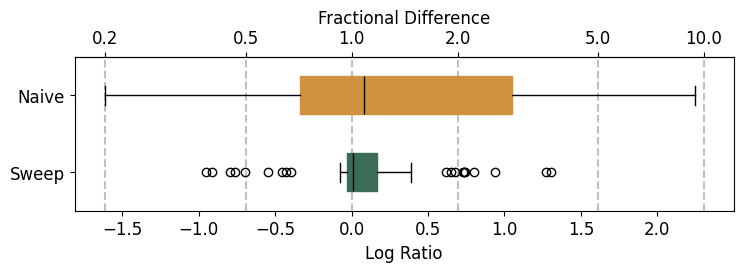

In [3]:


min_errors_all = []
min_errors_trunc = []

# combos_to_skip = ((1, 2, 3), (3, 1, 3), (5, 1, 2), (5, 1, 3), (9, 1, 3), (9, 2, 2), (9, 2, 3), (9, 3, 1), (9, 3, 2), (14, 2, 3), (14, 3, 1), (23, 3, 2))  
combos_to_skip = ((1, 3, 1), (1, 3, 2), (1, 3, 3), (3, 1, 1), (3, 2, 3), (3, 3, 3), (5, 1, 1), (5, 2, 2), (5, 2, 3), (14, 1, 1,), (14, 1, 2), (14, 1, 3), (23, 1, 2), (23, 1, 3), (23, 2,2)) 
# get every row in each bush/branch/trial combination 
for bush in metadata_df['bush'].unique():
    for branch in metadata_df[metadata_df['bush'] == bush]['branch'].unique():
        for trial in metadata_df[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch)]['trial'].unique():
            subset = metadata_df[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch) & (metadata_df['trial'] == trial)]
            
            min_error = min(subset['log_err'], key=abs)
            if (bush, branch, trial) in combos_to_skip:
                pass
            else:
                min_errors_trunc.append(min_error)
            min_errors_all.append(min_error)

# print(naive_errors_all)

fig, ax = plt.subplots(figsize=(8.5,2))
vert_lines = [1/5, 1/2, 1, 2, 5, 10]
for num in vert_lines:
    ax.axvline(x=np.log(num), color='gray', linestyle='--', alpha=0.5)
# plot a boxplot of the minimum errors
bplot = ax.boxplot([min_errors_all, metadata_naive_df['log_err']], vert=False, 
           labels=['Sweep', 'Naive'],
           patch_artist=True, 
           medianprops=dict(color='black'),
           widths=0.5)
box_colors = [cm.batlow(0.33), cm.batlow(0.66)]
for patch, color in zip(bplot['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
ax.set_xlabel('Log Ratio', fontsize=12)
# remove tick from y axis
# ax.set_yticks([])

ax.tick_params(axis='both', labelsize=12)
secax = ax.secondary_xaxis('top', functions=(lambda x: np.exp(x), lambda x: np.log(x)))
secax.set_xticks(vert_lines)
secax.set_xlabel('Fractional Difference', fontsize=12)
secax.tick_params(axis='x', labelsize=12)
plt.savefig(f"../images/min_errors_boxplot_v1_0.pdf", dpi=300, bbox_inches='tight')
plt.show()

Bush: 1, Branch: 1, Trial: 1
275
4
Bush: 1, Branch: 1, Trial: 2
275
4
Bush: 1, Branch: 1, Trial: 3
275
4
Bush: 1, Branch: 2, Trial: 1
275
4
Bush: 1, Branch: 2, Trial: 2
275
4
Bush: 1, Branch: 2, Trial: 3
275
4
Bush: 1, Branch: 3, Trial: 1
275
4
Bush: 1, Branch: 3, Trial: 2
275
4
Bush: 1, Branch: 3, Trial: 3
275
4
Bush: 3, Branch: 1, Trial: 1
275
4
Bush: 3, Branch: 1, Trial: 2
275
4
Bush: 3, Branch: 1, Trial: 3
275
4
Bush: 3, Branch: 2, Trial: 1
275
4
Bush: 3, Branch: 2, Trial: 2
275
4
Bush: 3, Branch: 2, Trial: 3
275
4
Bush: 3, Branch: 3, Trial: 1
275
4
Bush: 3, Branch: 3, Trial: 2
275
4
Bush: 3, Branch: 3, Trial: 3
275
4
Bush: 5, Branch: 1, Trial: 1
275
4
Bush: 5, Branch: 1, Trial: 2
275
4
Bush: 5, Branch: 1, Trial: 3
275
4
Bush: 5, Branch: 2, Trial: 1
275
4
Bush: 5, Branch: 2, Trial: 2
275
4
Bush: 5, Branch: 2, Trial: 3
275
4
Bush: 5, Branch: 3, Trial: 1
275
4
Bush: 5, Branch: 3, Trial: 2
275
4
Bush: 5, Branch: 3, Trial: 3
275
4
Bush: 9, Branch: 1, Trial: 1
275
4
Bush: 9, Branch: 1, 

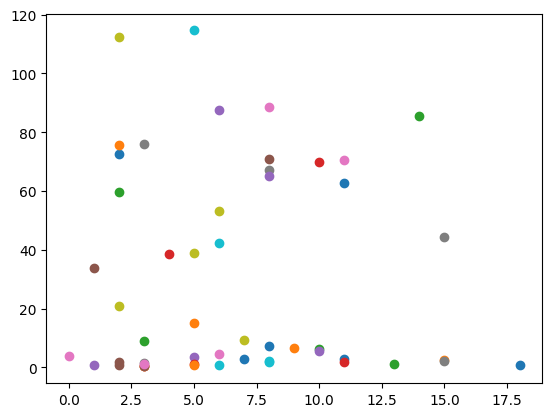

In [58]:
# load /data/results/change_point_counts.pkl
counts_df = pd.read_pickle('../data/results/change_point_counts.pkl')
# match the counts_df to the metadata_df by bush, branch, trial
# change the 1-2-3-4-5-6 indexing to the 1-3-5-9-14-23 indexing for bushes in metadata
bush_index_mapping = {1: 1, 2: 3, 3: 5, 4: 9, 5: 14, 6: 23}
counts_df['bush'] = [bush_index_mapping[b] for b in counts_df['bush']]

for bush in metadata_df['bush'].unique():
    for branch in metadata_df[metadata_df['bush'] == bush]['branch'].unique():
        for trial in metadata_df[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch)]['trial'].unique():
            subset = metadata_df[(metadata_df['bush'] == bush) & (metadata_df['branch'] == branch) & (metadata_df['trial'] == trial)]
            print(f"Bush: {bush}, Branch: {branch}, Trial: {trial}")
            min_error = subset['error'].min()
            # check that "subset" is not empty
            print(np.size(subset))
            print(np.size(counts_df[(counts_df['bush'] == bush) & (counts_df['branch'] == branch) & (counts_df['trial'] == trial)]))
            plt.plot(counts_df[(counts_df['bush'] == bush) & (counts_df['branch'] == branch) & (counts_df['trial'] == trial)]['change_point_count'], 
                     min_error*100, 'o', label=f"Bush {bush}, Branch {branch}, Trial {trial}")

plt.show()